# 60-day evaluation of resource-allocation policies

This notebook is the primary report study for the optimization evaluation and staffing management question. It includes the full policy grid and the leave-two-out stress test. Every simulation explicitly uses the active lifecycle: W_ service sessions are sampled from `simulation_inputs_active.json`, while A_/O_ records are automatic zero-time state changes that do not consume human capacity.

The experiment uses the deployed BPMN/Petri-net process, repaired decision-point probabilities, visit-aware branching, contextual OrgModel permissions, calendar availability, and common random numbers (CRN). The fitted distribution sampler is fixed as the basic report baseline before comparing policies; the separate Section 1.3 validation records its fit relative to the ML alternatives. The newly retrained decision-rule artifact is intentionally not used because this study's branching mode remains `visit`. Results and report hand-off values are written under horizon-specific names.

**Execution order.** Regenerate the controlled lifecycle comparison first,
then run this notebook. The 10- and 30-day notebooks are optional diagnostics
and are not prerequisites because the report uses only the 60-day study.

In [1]:
import hashlib
import importlib
import json
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "analysis").is_dir() and (path / "simulation").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if sys.prefix == sys.base_prefix:
    raise RuntimeError(
        'Select the registered BPIC17 (venv) kernel before running this notebook.'
    )
print(f'Notebook interpreter: {sys.executable}')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from analysis.availability import YearlyAvailability
from analysis.tum_style import (
    TUM_BLUE, TUM_GRAY, TUM_GRAY_DARK, TUM_ORANGE, TUM_RED, TUM_TEAL,
    apply_tum_style, save_figure,
)
from simulation.components import petri_process as petri_process_module
from simulation.components import process as process_module
from simulation.components import resource as resource_module
from scripts import opt_metrics as om
from scripts import run_experiments as R
from scripts.eval_lifecycle import validate_lifecycle_validation_artifact

# Notebook kernels can outlive source-code changes. Reload the project
# modules in dependency order so Run All always uses the current checkout.
resource_module = importlib.reload(resource_module)
process_module = importlib.reload(process_module)
petri_process_module = importlib.reload(petri_process_module)
om = importlib.reload(om)
R = importlib.reload(R)

apply_tum_style()
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DAY = 86_400.0
RESULT_DIR = ROOT / "output" / "evaluation_60"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_INPUT_DIR = ROOT / "output" / "report_inputs"
REPORT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSING_VALIDATION_PATH = ROOT / "output/validation/lifecycle_active/distribution.json"
if not PROCESSING_VALIDATION_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {PROCESSING_VALIDATION_PATH}; run python scripts/run_lifecycle_validation.py"
    )
validate_lifecycle_validation_artifact(
    json.loads(PROCESSING_VALIDATION_PATH.read_text()), "distribution"
)

Notebook interpreter: /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/venv/bin/python


## 1. Experimental design and provenance

Four paired replications balance precision and notebook runtime. The 60-day horizon gives long-running cases more time to reach completion and exposes every weekday roster pattern repeatedly. The study runs 56 policy replications and eight leave-two-out replications; the random-policy baseline is reused for staffing. Confidence intervals use Student's *t* distribution and should be read as simulation uncertainty, not uncertainty about the historical population.

The grid contains every fixed policy exposed by the experiment runner: R-RMA, R-RRA, R-SHQ, Piled Execution, Pull-SPT, Pull-LAF, Park--Song, and DRL. Because k-Batching and Kunkler--Rinderle-Ma are parameterized families rather than finite registries, their previously defined study grids are stated explicitly: $k\in\{1,5,10\}$ and $\delta\in\{0.5,1,2\}$. This is the complete configured comparison, not a claim that every positive value of $k$ or $\delta$ has been enumerated. Cycle time is calculated only for naturally completed cases; completion counts and milestone reach rates are reported with it to expose horizon truncation and survivorship effects. Resource metrics include every human in the active OrgModel pool, including staff who perform no work in a run. The calendar-designated automated account remains part of the process but is excluded from staffing metrics.

Every active run uses unit resource capacity and a seeded draw from the fitted `p_work` roster. Policies sharing a replication seed therefore face the same realized workforce. The evaluation seeds start above the four worker-seed bands implied by the archive's recorded seed and the current parallel trainer. The missing companion metadata nevertheless prevents a complete audit of all training and checkpoint-selection seeds, so DRL should be described as a technically compatible policy comparison rather than proof based on independently documented test data. A_/O_ milestones are treated as automatic zero-time state changes because the source log contains no service intervals for them. Cache provenance fingerprints the Petri net and decision-point tables, metric and simulation code, the DRL archive, policies, arrivals, permissions, availability, and lifecycle inputs; changing any of them invalidates the cached result.

In [2]:
SEEDS = [4_000_001, 4_000_002, 4_000_003, 4_000_004]
HORIZON_DAYS = 60
FIXED_POLICIES = [
    "random", "roundrobin", "shortestqueue", "piled",
    "pullspt", "pulllaf", "parksong", "drl",
]
KBATCH_POLICIES = ["kbatch1", "kbatch5", "kbatch10"]
KRM_POLICIES = ["krm0.5", "krm1", "krm2"]
POLICIES = FIXED_POLICIES + KBATCH_POLICIES + KRM_POLICIES
assert set(FIXED_POLICIES) == R.KNOWN_POLICIES, (FIXED_POLICIES, R.KNOWN_POLICIES)
assert len(POLICIES) == len(set(POLICIES)) and all(R.is_known_policy(p) for p in POLICIES)

DRL_MODEL_PATH = ROOT / "models/drl_resource_policy_rocm_v3_100k.zip"
if not DRL_MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {DRL_MODEL_PATH}. Place the supplied DRL ZIP there before Run All."
    )
missing_drl_packages = [
    package for package in ("gymnasium", "stable_baselines3", "sb3_contrib")
    if importlib.util.find_spec(package) is None
]
if missing_drl_packages:
    raise RuntimeError(
        "Missing optional DRL packages " + ", ".join(missing_drl_packages)
        + ". Run: python -m pip install -r requirements-drl.txt"
    )
DRL_MODEL_SHA256 = hashlib.sha256(DRL_MODEL_PATH.read_bytes()).hexdigest()
CACHE_SCHEMA_VERSION = 6
PROVENANCE_SHA256 = R.evaluation_provenance_hashes()
POLICY_LABELS = {
    "random": "R-RMA",
    "roundrobin": "R-RRA",
    "shortestqueue": "R-SHQ",
    "piled": "R-PE",
    "pullspt": "Pull-SPT",
    "pulllaf": "Pull-LAF",
    "parksong": "Park--Song",
    "drl": "DRL",
    "kbatch1": "k-Batching k=1",
    "kbatch5": "k-Batching k=5",
    "kbatch10": "k-Batching k=10",
    "krm0.5": "K-RM delta=0.5",
    "krm1": "K-RM delta=1",
    "krm2": "K-RM delta=2",
}
assert set(POLICY_LABELS) == set(POLICIES)

RUN_CONFIG = {
    "horizon_days": HORIZON_DAYS,
    "seeds": SEEDS,
    "scenario": "normal",
    "crn": True,
    "process_model": "advanced",
    "branching_mode": "visit",
    "permissions": "orgmodel",
    "lifecycle_mode": "active",
    "processing_time_mode": "distribution",
    "atomic_duration_scale": 0.0,
    "atomic_activity_mode": "automatic",
    "capacity": R.capacity_for_mode("active"),
    "roster_seed": R.DEFAULT_ROSTER_SEED,
    "arrival_model": "mdn" if R.USE_MDN_ARRIVALS else "parametric",
    "drl_model_path": str(DRL_MODEL_PATH.relative_to(ROOT)),
    "drl_model_sha256": DRL_MODEL_SHA256,
}

calendar = YearlyAvailability.from_json(ROOT / "models" / "availability_model.json")
permissions, _ = R.load_permission_model(RUN_CONFIG["permissions"], seed=SEEDS[0])
resource_pool = set(permissions.resources())
human_resources = resource_pool - calendar.system
automated_resources = resource_pool & calendar.system

# Load the model once before the long grid. ResourceComponent validates its
# observation and action spaces against the current OrgModel vocabulary.
drl_probe = R.build_resource_component(
    "drl", SEEDS[0], calendar, set(), permission_model=permissions,
    lifecycle_mode=RUN_CONFIG["lifecycle_mode"],
    lifecycle_params=R.LifecycleParameters.from_file(R.ACTIVE_INPUTS_PATH),
    capacity=RUN_CONFIG["capacity"], drl_model_path=str(DRL_MODEL_PATH),
    branching_mode=RUN_CONFIG["branching_mode"], automatic_atomic=True,
)
DRL_COMPATIBILITY = {
    "observation_size": drl_probe.drl_observation_size,
    "action_count": drl_probe.drl_action_count,
    "timesteps": int(drl_probe._drl_model.num_timesteps),
}
del drl_probe

print(json.dumps(RUN_CONFIG, indent=2))
print(json.dumps({"provenance_sha256": PROVENANCE_SHA256}, indent=2))
print(json.dumps({"drl_compatibility": DRL_COMPATIBILITY}, indent=2))
print(
    f"Active pool: {len(resource_pool)} resources = {len(human_resources)} human "
    f"+ {len(automated_resources)} automated {sorted(automated_resources)}"
)

{
  "horizon_days": 60,
  "seeds": [
    4000001,
    4000002,
    4000003,
    4000004
  ],
  "scenario": "normal",
  "crn": true,
  "process_model": "advanced",
  "branching_mode": "visit",
  "permissions": "orgmodel",
  "lifecycle_mode": "active",
  "processing_time_mode": "distribution",
  "atomic_duration_scale": 0.0,
  "atomic_activity_mode": "automatic",
  "capacity": 1,
  "roster_seed": 42,
  "arrival_model": "mdn",
  "drl_model_path": "models/drl_resource_policy_rocm_v3_100k.zip",
  "drl_model_sha256": "4c44ac7dc9abadcf997dffb2079001d46c66e476ab84637282756f7cdc7840cd"
}
{
  "provenance_sha256": {
    "analysis/availability.py": "279cfe7671ae25009ecdf9efd604ac0f75715605489d4b2885e992190993f2f3",
    "analysis/permissions.py": "45f3720d45863f6e36de5dea408e21a25466ad984c6c9a86b1206cfad3f860d5",
    "models/availability_model.json": "6611bc99ceb5e9d9e740368f2b669fc123f25ac711e2925a0112b3a3dd196ebf",
    "models/case_attributes.json": "97b2c091c50c0bc7ad247215dd4bcfbf2de622be0a5b88

In [3]:
def ci95(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) < 2:
        return np.nan
    return float(stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values)))


def expected_roster_seed(seed):
    base = RUN_CONFIG["roster_seed"]
    return None if base is None else base + seed


def assert_cached_diagnostics(cached, seed):
    row = cached["row"]
    assert row["effective_capacity"] == RUN_CONFIG["capacity"]
    assert row["effective_roster_seed"] == expected_roster_seed(seed)
    assert row["arrival_model"] == RUN_CONFIG["arrival_model"]
    assert row["atomic_duration_scale"] == RUN_CONFIG["atomic_duration_scale"]
    assert row["atomic_activity_mode"] == RUN_CONFIG["atomic_activity_mode"]
    assert row["automatic_atomic_transitions"] > 0
    assert row["assigned_atomic_starts"] == 0
    assert row["ao_busy_share"] == 0.0
    assert row["unpermitted_activities"] == 0
    assert row["missing_resource_starts"] == 0
    assert row["still_queued_at_end"] >= 0
    assert row["max_session_guard_reached"] == 0
    assert row["max_session_guard_forced_completions"] == 0
    if row["policy"] == "drl":
        assert row["drl_assignments"] > 0
        assert row["drl_postponements"] >= 0
    if row["effective_capacity"] == 1:
        assert row["max_resource_occupation"] <= 1.0 + 1e-9


def run_and_measure(
    policy, seed, *, excluded=None, resource_subset=None, cache_key="policy",
):
    subset = human_resources if resource_subset is None else set(resource_subset)
    excluded_set = set(excluded or ())
    effective_roster_seed = expected_roster_seed(seed)
    effective_drl_model_path = str(DRL_MODEL_PATH) if policy == "drl" else None
    cache_dir = RESULT_DIR / "run_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{cache_key}_{policy}_seed{seed}.json"
    cache_configuration = {
        **RUN_CONFIG,
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "provenance_sha256": PROVENANCE_SHA256,
        "effective_capacity": RUN_CONFIG["capacity"],
        "effective_roster_seed": effective_roster_seed,
        "policy": policy,
        "seed": seed,
        "excluded_resources": sorted(excluded_set),
        "resource_subset": sorted(subset),
        "atomic_duration_scale": RUN_CONFIG["atomic_duration_scale"],
        "effective_drl_model_path": effective_drl_model_path,
    }
    if cache_path.exists():
        cached = json.loads(cache_path.read_text())
        if cached.get("cache_configuration") == cache_configuration:
            assert_cached_diagnostics(cached, seed)
            print(f"cached   policy={policy:>8} seed={seed} completed={cached['row']['completed_cases']:4d}")
            return cached

    df, meta = R.run_once(
        policy,
        seed,
        HORIZON_DAYS,
        RUN_CONFIG["scenario"],
        RUN_CONFIG["crn"],
        RUN_CONFIG["process_model"],
        RUN_CONFIG["branching_mode"],
        lifecycle_mode=RUN_CONFIG["lifecycle_mode"],
        processing_time_mode=RUN_CONFIG["processing_time_mode"],
        permissions=RUN_CONFIG["permissions"],
        excluded_override=excluded,
        roster_seed=RUN_CONFIG["roster_seed"],
        capacity=RUN_CONFIG["capacity"],
        atomic_duration_scale=RUN_CONFIG["atomic_duration_scale"],
        drl_model_path=effective_drl_model_path,
    )
    expected = {
        "horizon_days": HORIZON_DAYS,
        "scenario": RUN_CONFIG["scenario"],
        "crn": RUN_CONFIG["crn"],
        "process_model": RUN_CONFIG["process_model"],
        "branching_mode": RUN_CONFIG["branching_mode"],
        "permissions": RUN_CONFIG["permissions"],
        "lifecycle_mode": RUN_CONFIG["lifecycle_mode"],
        "processing_time_mode": RUN_CONFIG["processing_time_mode"],
        "atomic_duration_scale": RUN_CONFIG["atomic_duration_scale"],
        "atomic_activity_mode": RUN_CONFIG["atomic_activity_mode"],
        "capacity": RUN_CONFIG["capacity"],
        "roster_seed": effective_roster_seed,
        "arrival_model": RUN_CONFIG["arrival_model"],
        "drl_model_path": effective_drl_model_path,
    }
    for key, value in expected.items():
        assert meta["configuration"][key] == value, (key, meta["configuration"])
    assert "work_item_id" in df.columns and df["work_item_id"].notna().any()
    assert set(meta["resource_subset"]) == subset

    metrics = om.evaluate(
        df,
        arrival_times=meta["arrival_times"],
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        completed_case_ids=meta["completed_case_ids"],
        resource_subset=subset,
        evaluation_window=meta["evaluation_window"],
    )
    work_occupation = om.average_resource_occupation(
        df,
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        resource_subset=subset,
        activity_prefixes=("W_",),
        evaluation_window=meta["evaluation_window"],
    )
    work_fairness = om.resource_fairness(work_occupation["per_resource"])
    work_switching = om.resource_activity_switch_rate(
        df, activity_prefixes=("W_",), evaluation_window=meta["evaluation_window"]
    )
    work_balance = om.rolling_workload_balance(
        df, resource_subset=subset, activity_prefixes=("W_",),
        evaluation_window=meta["evaluation_window"],
    )
    lifecycle = meta["lifecycle_diagnostics"]
    exposure = meta["activity_type_exposure"]
    diagnostics = R.validate_resource_diagnostics(
        df,
        meta["resource_stats"],
        metrics["occupation"]["per_resource"],
        meta["configuration"]["capacity"],
    )
    custom = metrics["custom_metrics"]
    arrivals = len(meta["arrival_times"])
    completed = metrics["case_filter"]["n_cases_completed"]
    first_offer = custom["time_to_first_offer"]
    decision = custom["time_to_decision"]
    row = {
        "policy": policy,
        "seed": seed,
        "excluded_resources": ",".join(meta["configuration"]["excluded_resources"]),
        "effective_capacity": meta["configuration"]["capacity"],
        "effective_roster_seed": meta["configuration"]["roster_seed"],
        "arrival_model": meta["configuration"]["arrival_model"],
        "atomic_duration_scale": meta["configuration"]["atomic_duration_scale"],
        "atomic_activity_mode": meta["configuration"]["atomic_activity_mode"],
        "drl_assignments": meta["resource_stats"].get("drl_assignments", 0),
        "drl_postponements": meta["resource_stats"].get("drl_postponements", 0),
        **diagnostics,
        "arrivals": arrivals,
        "completed_cases": completed,
        "completion_share": completed / arrivals if arrivals else np.nan,
        "cycle_time_days": metrics["cycle_time"]["avg_cycle_time_s"] / DAY,
        "p95_cycle_days": metrics["cycle_time"]["p95_cycle_time_s"] / DAY,
        "occupation": metrics["occupation"]["avg_resource_occupation"],
        "fairness": metrics["fairness"]["resource_fairness"],
        "w_occupation": work_occupation["avg_resource_occupation"],
        "w_fairness": work_fairness["resource_fairness"],
        "time_to_first_offer_days": first_offer["mean_s"] / DAY,
        "first_offer_reach_share": first_offer["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "time_to_decision_days": decision["mean_s"] / DAY,
        "decision_reach_share": decision["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "case_handover_rate": custom["handover_rate"]["handover_rate"],
        "activity_switch_rate": custom["resource_activity_switch_rate"]["activity_switch_rate"],
        "rolling_workload_std": custom["rolling_workload_balance"]["mean_window_std"],
        "w_activity_switch_rate": work_switching["activity_switch_rate"],
        "w_rolling_workload_std": work_balance["mean_window_std"],
        "w_event_share": exposure["w_event_share"],
        "ao_event_share": exposure["ao_event_share"],
        "w_busy_share": exposure["w_busy_share"],
        "ao_busy_share": exposure["ao_busy_share"],
        "median_sessions_per_work_item": lifecycle["median_sessions_per_work_item"],
        "max_sessions_per_work_item": lifecycle["max_sessions_per_work_item"],
        "max_session_guard_reached": lifecycle["max_session_guard_reached"],
        "max_session_guard_forced_completions": lifecycle["max_session_guard_forced_completions"],
        "withdrawals": lifecycle["withdrawals"],
        "rare_shortened_work_items": lifecycle["rare_work_items_routed"].get("W_Shortened completion ", 0),
        "rare_personal_loan_work_items": lifecycle["rare_work_items_routed"].get("W_Personal Loan collection", 0),
        "resources_evaluated": metrics["occupation"]["n_resources_evaluated"],
        "zero_availability_resources": metrics["occupation"]["n_resources_zero_availability"],
        "busy_outside_availability_hours": (
            metrics["occupation"]["busy_seconds_outside_availability"] / 3600.0
        ),
    }
    instances = om.paired_instances(df)
    human_counts = instances.loc[
        instances["resource"].isin(human_resources), "resource"
    ].value_counts()
    work_human_counts = instances.loc[
        instances["resource"].isin(human_resources)
        & instances["activity"].fillna("").str.startswith("W_"),
        "resource",
    ].value_counts()
    result = {
        "cache_configuration": cache_configuration,
        "row": row,
        "resource_stats": meta["resource_stats"],
        "resource_occupation": metrics["occupation"]["per_resource"],
        "w_resource_occupation": work_occupation["per_resource"],
        "lifecycle_diagnostics": lifecycle,
        "activity_type_exposure": exposure,
        "human_throughput_share": (
            (human_counts / human_counts.sum()).to_dict() if human_counts.sum() else {}
        ),
        "w_human_throughput_share": (
            (work_human_counts / work_human_counts.sum()).to_dict()
            if work_human_counts.sum() else {}
        ),
    }
    assert_cached_diagnostics(result, seed)
    cache_path.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
    print(f"finished policy={policy:>8} seed={seed} completed={completed:4d}")
    return result


def summarize(rows, group="policy"):
    frame = pd.DataFrame(rows)
    metrics = [
        "cycle_time_days", "p95_cycle_days", "occupation", "fairness",
        "w_occupation", "w_fairness",
        "completed_cases", "completion_share", "time_to_first_offer_days",
        "first_offer_reach_share", "time_to_decision_days", "decision_reach_share",
        "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
        "w_activity_switch_rate", "w_rolling_workload_std",
        "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
        "median_sessions_per_work_item", "max_sessions_per_work_item",
        "max_session_guard_reached", "max_session_guard_forced_completions",
        "withdrawals", "rare_shortened_work_items",
        "rare_personal_loan_work_items",
    ]
    records = []
    for name, part in frame.groupby(group, sort=False):
        record = {group: name, "n_replications": len(part)}
        for metric in metrics:
            record[metric] = part[metric].mean()
            record[f"{metric}_ci95"] = ci95(part[metric])
        records.append(record)
    return pd.DataFrame(records).set_index(group), frame

## 2. Policy comparison

The following cell performs 56 active-lifecycle simulations over a 60-day horizon. Each run is checkpointed as JSON immediately after completion. A checkpoint is reused only when the full configuration, cache schema, effective capacity and roster seed, DRL archive hash, and every code-and-input fingerprint match. Cached and fresh runs pass the same resource guardrails. The checkpoints are local derived artifacts; only aggregate result tables are versioned.

In [4]:
policy_runs = {
    policy: [run_and_measure(policy, seed) for seed in SEEDS]
    for policy in POLICIES
}
policy_summary, policy_run_metrics = summarize(
    [run["row"] for runs in policy_runs.values() for run in runs]
)

policy_run_metrics.to_csv(RESULT_DIR / "policy_run_metrics.csv", index=False)
policy_summary.to_csv(RESULT_DIR / "policy_summary.csv")
(RESULT_DIR / "configuration.json").write_text(json.dumps({
    **RUN_CONFIG,
    "cache_schema_version": CACHE_SCHEMA_VERSION,
    "provenance_sha256": PROVENANCE_SHA256,
    "drl_compatibility": DRL_COMPATIBILITY,
    "effective_roster_seed_by_seed": {
        str(seed): expected_roster_seed(seed) for seed in SEEDS
    },
    "policies": POLICIES,
    "policy_run_count": len(POLICIES) * len(SEEDS),
    "notebook_simulation_run_count": len(POLICIES) * len(SEEDS) + 2 * len(SEEDS),
    "resource_pool_size": len(resource_pool),
    "human_resource_count": len(human_resources),
    "automated_resources": sorted(automated_resources),
}, indent=2) + "\n")

display_columns = [
    "cycle_time_days", "completed_cases", "completion_share", "occupation",
    "fairness", "w_occupation", "w_fairness", "activity_switch_rate",
    "w_activity_switch_rate", "time_to_decision_days", "decision_reach_share",
]
policy_summary[display_columns].rename(index=POLICY_LABELS).round(3)

[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 215060, Cases started: 4348, Cases completed: 3174, Wall time: 30.824s
finished policy=  random seed=4000001 completed=3174
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 216625, Cases started: 4309, Cases completed: 3161, Wall time: 29.642s
finished policy=  random seed=4000002 completed=3161
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 228577, Cases started: 4541, Cases completed: 3383, Wall time: 31.852s
finished policy=  random seed=4000003 completed=3383
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 210055, Cases started: 4199, Cases completed: 3161, Wall time: 30.008s
finished policy=  random seed=4000004 completed=3161
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 215051, Cases start

,cycle_time_days,completed_cases,completion_share,occupation,fairness,w_occupation,w_fairness,activity_switch_rate,w_activity_switch_rate,time_to_decision_days,decision_reach_share
policy,,,,,,,,,,,
R-RMA,0.698,"3,219.750",0.740,0.042,0.038,0.042,0.038,0.132,0.132,0.133,0.531
R-RRA,0.698,"3,219.500",0.740,0.041,0.038,0.041,0.038,0.140,0.140,0.133,0.531
R-SHQ,0.696,"3,219.750",0.740,0.062,0.056,0.062,0.056,0.110,0.110,0.133,0.531
R-PE,0.689,"3,219.250",0.740,0.041,0.039,0.041,0.039,0.130,0.130,0.133,0.531
Pull-SPT,0.695,"3,219.500",0.740,0.037,0.050,0.037,0.050,0.070,0.070,0.133,0.531
Pull-LAF,0.698,"3,222.000",0.741,0.037,0.050,0.037,0.050,0.071,0.071,0.133,0.531
Park--Song,0.693,"3,220.500",0.741,0.042,0.056,0.042,0.056,0.110,0.110,0.133,0.531
DRL,0.699,"3,220.000",0.740,0.037,0.050,0.037,0.050,0.060,0.060,0.133,0.531
k-Batching k=1,0.773,"3,335.000",0.767,0.043,0.056,0.043,0.056,0.094,0.094,0.189,0.552


In [5]:
def paired_deltas(frame, baseline="random"):
    columns = ["cycle_time_days", "completed_cases", "activity_switch_rate", "time_to_decision_days"]
    records = []
    base = frame[frame["policy"] == baseline].set_index("seed")
    for policy in POLICIES:
        if policy == baseline:
            continue
        other = frame[frame["policy"] == policy].set_index("seed")
        common = base.index.intersection(other.index)
        record = {"policy_vs_random": policy, "n_pairs": len(common)}
        for column in columns:
            delta = other.loc[common, column] - base.loc[common, column]
            record[f"delta_{column}"] = delta.mean()
            record[f"delta_{column}_ci95"] = ci95(delta)
        records.append(record)
    return pd.DataFrame(records).set_index("policy_vs_random")


policy_deltas = paired_deltas(policy_run_metrics)
policy_deltas.to_csv(RESULT_DIR / "policy_paired_deltas.csv")
policy_deltas.round(3)

,n_pairs,delta_cycle_time_days,delta_cycle_time_days_ci95,delta_completed_cases,delta_completed_cases_ci95,delta_activity_switch_rate,delta_activity_switch_rate_ci95,delta_time_to_decision_days,delta_time_to_decision_days_ci95
policy_vs_random,,,,,,,,,
roundrobin,4,-0.000,0.003,-0.250,0.796,0.008,0.006,-0.000,0.000
shortestqueue,4,-0.001,0.003,0.000,0.000,-0.021,0.006,-0.000,0.000
piled,4,-0.009,0.016,-0.500,1.591,-0.002,0.003,0.000,0.000
pullspt,4,-0.003,0.006,-0.250,1.523,-0.061,0.005,-0.000,0.000
pulllaf,4,-0.000,0.017,2.250,3.012,-0.060,0.006,-0.000,0.000
parksong,4,-0.005,0.006,0.750,1.523,-0.021,0.015,-0.000,0.001
drl,4,0.001,0.005,0.250,0.796,-0.072,0.007,0.000,0.001
kbatch1,4,0.075,0.052,115.250,27.907,-0.038,0.009,0.056,0.014
kbatch5,4,0.070,0.025,120.000,21.506,-0.061,0.005,0.039,0.010


The compact trade-off plot is retained because it combines the two outcome measures needed to detect survivorship: lower cycle time is only desirable when it is not obtained by completing fewer cases. The remaining measures are more legible in the tables than as separate charts.

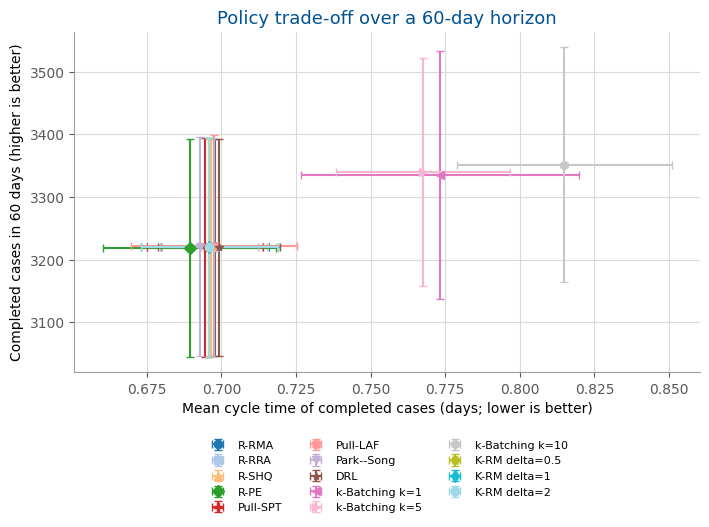

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
colors = plt.colormaps["tab20"](np.linspace(0, 1, len(POLICIES)))
markers = ["o", "s", "^", "D", "P", "X", "v", "*", "<", ">", "h", "H", "d", "8"]
for color, marker, policy in zip(colors, markers, POLICIES):
    row = policy_summary.loc[policy]
    ax.errorbar(
        row["cycle_time_days"], row["completed_cases"],
        xerr=row["cycle_time_days_ci95"], yerr=row["completed_cases_ci95"],
        fmt=marker, ms=6, capsize=3, color=color, label=POLICY_LABELS[policy],
    )
ax.set_xlabel("Mean cycle time of completed cases (days; lower is better)", fontsize=10)
ax.set_ylabel(f"Completed cases in {HORIZON_DAYS} days (higher is better)", fontsize=10)
ax.set_title(f"Policy trade-off over a {HORIZON_DAYS}-day horizon", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.17))
fig.tight_layout()
fig.subplots_adjust(bottom=0.30)
save_figure(fig, "04_60_policy_tradeoff")
plt.show()

### Operational diagnostics

The case-handover rate describes continuity within one customer case. It is not a direct test of Piled Execution. Piled Execution instead tries to keep a resource on the same activity, so `activity_switch_rate` is the relevant mechanism measure. A_/O_ state changes remain visible as event rows but have no resource assignment or busy time; the W_-only and all-activity resource measures should therefore coincide. Milestone means are accompanied by the share of arrivals that reach each milestone; comparing means alone would condition on a policy-dependent subset of cases.

In [7]:
diagnostic_columns = [
    "time_to_first_offer_days", "first_offer_reach_share",
    "time_to_decision_days", "decision_reach_share",
    "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
    "w_activity_switch_rate", "w_rolling_workload_std",
    "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
    "median_sessions_per_work_item", "max_sessions_per_work_item",
    "max_session_guard_reached", "max_session_guard_forced_completions",
    "withdrawals", "rare_shortened_work_items",
    "rare_personal_loan_work_items",
]
policy_summary[diagnostic_columns].rename(index=POLICY_LABELS).round(3)

,time_to_first_offer_days,first_offer_reach_share,time_to_decision_days,decision_reach_share,case_handover_rate,activity_switch_rate,rolling_workload_std,w_activity_switch_rate,w_rolling_workload_std,w_event_share,ao_event_share,w_busy_share,ao_busy_share,median_sessions_per_work_item,max_sessions_per_work_item,max_session_guard_reached,max_session_guard_forced_completions,withdrawals,rare_shortened_work_items,rare_personal_loan_work_items
policy,,,,,,,,,,,,,,,,,,,,
R-RMA,0.000,0.977,0.133,0.531,0.814,0.132,0.025,0.132,0.025,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,319.000,0.000,0.000
R-RRA,0.000,0.977,0.133,0.531,0.830,0.140,0.025,0.140,0.025,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,319.000,0.000,0.000
R-SHQ,0.000,0.977,0.133,0.531,0.713,0.110,0.026,0.110,0.026,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,319.250,0.000,0.000
R-PE,0.000,0.977,0.133,0.531,0.788,0.130,0.025,0.130,0.025,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,319.750,0.000,0.000
Pull-SPT,0.000,0.977,0.133,0.531,0.549,0.070,0.029,0.070,0.029,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,317.500,0.000,0.000
Pull-LAF,0.000,0.977,0.133,0.531,0.513,0.071,0.030,0.071,0.030,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,320.000,0.000,0.000
Park--Song,0.000,0.977,0.133,0.531,0.539,0.110,0.030,0.110,0.030,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,320.000,0.000,0.000
DRL,0.000,0.977,0.133,0.531,0.562,0.060,0.029,0.060,0.029,0.194,0.806,1.000,0.000,1.000,11.000,0.000,0.000,319.750,0.000,0.000
k-Batching k=1,0.000,0.985,0.189,0.552,0.589,0.094,0.031,0.094,0.031,0.191,0.809,1.000,0.000,1.000,11.000,0.000,0.000,680.500,0.000,0.000


### Automatic A_/O_ state-change assumption

BPIC-17 does not provide start/complete intervals for A_ and O_ records. The evaluation therefore models them as automatic state changes at the same timestamp (`atomic_duration_scale=0`): they bypass permission checks, calendars, policy selection, queues, and resource capacity. This avoids assigning invented service time to most event rows. It is also a limitation, because any unobserved human effort or delay behind these milestones is outside the simulation. W_ session durations and resource allocation remain empirical model components.

In [9]:
atomic_assumption_summary = (
    policy_run_metrics.groupby("policy")[
        ["ao_event_share", "ao_busy_share", "w_busy_share",
         "automatic_atomic_transitions", "assigned_atomic_starts"]
    ].mean()
)
assert policy_run_metrics["atomic_duration_scale"].eq(0.0).all()
assert policy_run_metrics["atomic_activity_mode"].eq("automatic").all()
assert policy_run_metrics["automatic_atomic_transitions"].gt(0).all()
assert policy_run_metrics["assigned_atomic_starts"].eq(0).all()
assert policy_run_metrics["ao_busy_share"].eq(0.0).all()
assert np.isclose(
    policy_run_metrics["w_busy_share"], 1.0, rtol=0.0, atol=1e-12
).all()
atomic_assumption_summary.rename(index=POLICY_LABELS).round(3)

,ao_event_share,ao_busy_share,w_busy_share,automatic_atomic_transitions,assigned_atomic_starts
policy,,,,,
DRL,0.806,0.000,1.000,"54,460.000",0.000
k-Batching k=1,0.809,0.000,1.000,"55,474.500",0.000
k-Batching k=10,0.810,0.000,1.000,"55,863.750",0.000
k-Batching k=5,0.809,0.000,1.000,"55,717.500",0.000
K-RM delta=0.5,0.806,0.000,1.000,"54,458.250",0.000
K-RM delta=1,0.806,0.000,1.000,"54,458.250",0.000
K-RM delta=2,0.806,0.000,1.000,"54,458.250",0.000
Park--Song,0.806,0.000,1.000,"54,467.500",0.000
R-PE,0.806,0.000,1.000,"54,450.000",0.000


## 3. Staffing question: which two employees can be removed with the least operational harm?

The previous report treated a 17-resource legacy map as the deployed workforce and claimed that `User_5` was an exclusive permission holder. The current OrgModel contains 144 resources. We therefore recompute the candidate pool and permission redundancy from the model actually used by the simulator.

Criticality is a screening score, not a causal estimate. It combines W_ occupation, W_ throughput share, and permission breadth; automatic A_/O_ state changes do not belong in a human staffing score. A human who is the sole candidate for a recognized `(activity, case type, weekday)` context is excluded from removal rather than folded into the weighted score. The leave-two-out simulations then test the two lowest-scoring eligible employees against a deliberately high-criticality contrast under the same paired seeds.

In [10]:
# Contextual permission redundancy in the deployed OrgModel.
model_case_types = sorted({
    case_type
    for entries in permissions._index.values()
    for _, case_type, _ in entries
    if case_type
}) or [None]
model_weekdays = pd.date_range("2016-01-04", periods=7, freq="D")
sole_candidate_contexts = pd.Series(0, index=sorted(human_resources), dtype=int)
recognized_contexts = 0
for activity in permissions._index:
    for case_type in model_case_types:
        for when in model_weekdays:
            candidates = set(permissions.candidates(activity, case_type=case_type, when=when)) & human_resources
            if candidates:
                recognized_contexts += 1
            if len(candidates) == 1:
                sole_candidate_contexts.loc[next(iter(candidates))] += 1

base_runs = policy_runs["random"]
occupation_by_resource = pd.DataFrame([
    run["w_resource_occupation"] for run in base_runs
]).reindex(columns=sorted(human_resources), fill_value=0.0).mean()

throughput_frames = [
    pd.Series(run["w_human_throughput_share"], dtype=float) for run in base_runs
]
throughput_share = pd.concat(throughput_frames, axis=1).reindex(sorted(human_resources)).fillna(0.0).mean(axis=1)

permission_breadth = pd.Series({
    resource: sum(
        any(resource in members for members, _, _ in entries)
        for entries in permissions._index.values()
    )
    for resource in human_resources
})

def normalize(series):
    span = series.max() - series.min()
    return (series - series.min()) / span if span else pd.Series(0.0, index=series.index)

criticality = pd.DataFrame({
    "occupation": occupation_by_resource,
    "throughput_share": throughput_share,
    "permission_breadth": permission_breadth,
    "sole_candidate_contexts": sole_candidate_contexts,
}).reindex(sorted(human_resources)).fillna(0.0)
criticality["criticality_score"] = (
    0.4 * normalize(criticality["occupation"])
    + 0.4 * normalize(criticality["throughput_share"])
    + 0.2 * normalize(criticality["permission_breadth"])
)
criticality = criticality.sort_values("criticality_score")
protected_resources = set(criticality.index[criticality["sole_candidate_contexts"] > 0])
removal_candidates = criticality.drop(index=protected_resources)
if protected_resources:
    print("Protected from removal due to sole-candidate contexts:", sorted(protected_resources))
criticality.to_csv(RESULT_DIR / "resource_criticality.csv")

print(f"Recognized OrgModel contexts checked: {recognized_contexts}")
print(f"Single-human-candidate contexts: {int(sole_candidate_contexts.sum())}")
display(pd.concat([criticality.head(6), criticality.tail(6)]).round(4))

Recognized OrgModel contexts checked: 1735
Single-human-candidate contexts: 0


,occupation,throughput_share,permission_breadth,sole_candidate_contexts,criticality_score
User_128,0.000,0.000,10,0,0.017
User_136,0.000,0.000,10,0,0.017
User_135,0.000,0.000,10,0,0.017
User_134,0.000,0.000,10,0,0.017
User_131,0.000,0.000,10,0,0.017
User_130,0.000,0.000,10,0,0.017
User_83,0.160,0.019,21,0,0.501
User_29,0.138,0.030,21,0,0.507
User_30,0.177,0.048,21,0,0.628
User_87,0.205,0.037,21,0,0.628


In [11]:
remove_low = list(removal_candidates.index[:2])
remove_high = list(removal_candidates.index[-2:])
print("Low-criticality pair:", remove_low)
print("High-criticality contrast:", remove_high)

staffing_runs = {
    "baseline": base_runs,
    "remove_low": [
        run_and_measure(
            "random", seed, excluded=set(remove_low),
            resource_subset=human_resources - set(remove_low), cache_key="remove_low",
        )
        for seed in SEEDS
    ],
    "remove_high": [
        run_and_measure(
            "random", seed, excluded=set(remove_high),
            resource_subset=human_resources - set(remove_high), cache_key="remove_high",
        )
        for seed in SEEDS
    ],
}

staffing_summary, staffing_run_metrics = summarize([
    {**run["row"], "staffing_scenario": scenario}
    for scenario, runs in staffing_runs.items()
    for run in runs
], group="staffing_scenario")
staffing_run_metrics.to_csv(RESULT_DIR / "staffing_run_metrics.csv", index=False)
staffing_summary.to_csv(RESULT_DIR / "staffing_summary.csv")
display(staffing_summary[[
    "cycle_time_days", "completed_cases", "completion_share", "occupation",
    "fairness", "w_occupation", "w_fairness",
    "time_to_decision_days", "decision_reach_share",
]].round(3))

staffing_delta_records = []
staffing_base = staffing_run_metrics[
    staffing_run_metrics["staffing_scenario"] == "baseline"
].set_index("seed")
for scenario in ["remove_low", "remove_high"]:
    other = staffing_run_metrics[
        staffing_run_metrics["staffing_scenario"] == scenario
    ].set_index("seed")
    common = staffing_base.index.intersection(other.index)
    record = {"staffing_scenario_vs_baseline": scenario, "n_pairs": len(common)}
    for metric in [
        "cycle_time_days", "completed_cases", "occupation", "fairness",
        "w_occupation", "w_fairness",
        "time_to_decision_days", "decision_reach_share",
    ]:
        delta = other.loc[common, metric] - staffing_base.loc[common, metric]
        record[f"delta_{metric}"] = delta.mean()
        record[f"delta_{metric}_ci95"] = ci95(delta)
    staffing_delta_records.append(record)
staffing_paired_deltas = pd.DataFrame(staffing_delta_records).set_index(
    "staffing_scenario_vs_baseline"
)
staffing_paired_deltas.to_csv(RESULT_DIR / "staffing_paired_deltas.csv")
staffing_paired_deltas.round(3)

Low-criticality pair: ['User_128', 'User_136']
High-criticality contrast: ['User_68', 'User_75']
cached   policy=  random seed=4000001 completed=3174
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 216625, Cases started: 4309, Cases completed: 3161, Wall time: 30.043s
finished policy=  random seed=4000002 completed=3161
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 228577, Cases started: 4541, Cases completed: 3383, Wall time: 31.288s
finished policy=  random seed=4000003 completed=3383
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 210055, Cases started: 4199, Cases completed: 3161, Wall time: 29.095s
finished policy=  random seed=4000004 completed=3161
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 214516, Cases started: 4348, Cases completed: 3166, Wall time: 29.823s
finished policy=  r

,cycle_time_days,completed_cases,completion_share,occupation,fairness,w_occupation,w_fairness,time_to_decision_days,decision_reach_share
staffing_scenario,,,,,,,,,
baseline,0.698,"3,219.750",0.740,0.042,0.038,0.042,0.038,0.133,0.531
remove_low,0.698,"3,219.750",0.740,0.042,0.039,0.042,0.039,0.133,0.531
remove_high,0.725,"3,215.000",0.739,0.047,0.047,0.047,0.047,0.134,0.531


,n_pairs,delta_cycle_time_days,delta_cycle_time_days_ci95,delta_completed_cases,delta_completed_cases_ci95,delta_occupation,delta_occupation_ci95,delta_fairness,delta_fairness_ci95,delta_w_occupation,delta_w_occupation_ci95,delta_w_fairness,delta_w_fairness_ci95,delta_time_to_decision_days,delta_time_to_decision_days_ci95,delta_decision_reach_share,delta_decision_reach_share_ci95
staffing_scenario_vs_baseline,,,,,,,,,,,,,,,,,
remove_low,4,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000
remove_high,4,0.028,0.010,-4.750,6.281,0.005,0.002,0.008,0.002,0.005,0.002,0.008,0.002,0.000,0.001,0.000,0.000


In [12]:
baseline = staffing_summary.loc["baseline"]
impact = pd.DataFrame({
    scenario: {
        "Cycle time": 100 * (staffing_summary.loc[scenario, "cycle_time_days"] / baseline["cycle_time_days"] - 1),
        "Completed cases": 100 * (staffing_summary.loc[scenario, "completed_cases"] / baseline["completed_cases"] - 1),
        "Time to decision": 100 * (staffing_summary.loc[scenario, "time_to_decision_days"] / baseline["time_to_decision_days"] - 1),
    }
    for scenario in ["remove_low", "remove_high"]
}).T
impact.to_csv(RESULT_DIR / "staffing_relative_impact.csv")
impact.round(2)

,Cycle time,Completed cases,Time to decision
remove_low,0.000,0.000,0.000
remove_high,3.950,-0.150,0.290


The staffing chart is retained because the signs of the changes matter: a lower cycle-time mean can coexist with fewer completions and therefore indicate survivorship rather than improvement. The table remains the source for exact values.

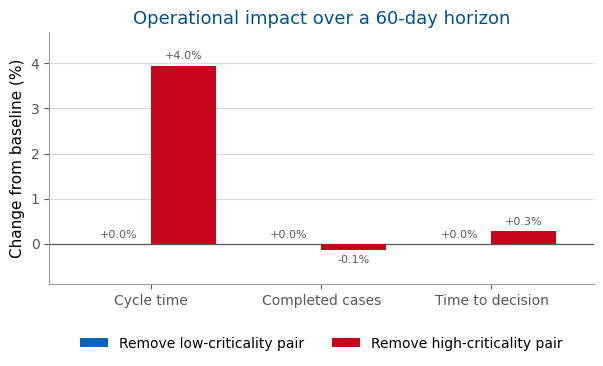

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
metrics = list(impact.columns)
x = np.arange(len(metrics))
width = 0.38
for offset, (scenario, color, label) in enumerate([
    ("remove_low", TUM_BLUE, "Remove low-criticality pair"),
    ("remove_high", TUM_RED, "Remove high-criticality pair"),
]):
    values = impact.loc[scenario].to_numpy()
    bars = ax.bar(x + (offset - 0.5) * width, values, width,
                  color=color, label=label, zorder=3)
    ax.bar_label(bars, fmt="%+.1f%%", fontsize=8, padding=3, color=TUM_GRAY_DARK)

ax.axhline(0, color=TUM_GRAY_DARK, lw=0.9, zorder=2)

lo, hi = impact.to_numpy().min(), impact.to_numpy().max()
pad = 0.18 * (hi - lo)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_xlim(-0.6, len(metrics) - 0.4)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Change from baseline (%)", fontsize=11)
ax.set_title(f"Operational impact over a {HORIZON_DAYS}-day horizon", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(fontsize=10, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)

fig.tight_layout()
fig.subplots_adjust(bottom=0.24)
save_figure(fig, "04_60_staffing_impact")
plt.show()

## 4. Reproducibility checks and interpretation guardrails

- The runner requires `lifecycle_mode` as a keyword, so future notebooks cannot silently fall back to legacy elapsed durations.
- Every run records and checks its effective capacity, realized roster seed, and arrival model. Policies with the same replication seed use the same roster draw.
- Cache keys also fingerprint the Petri net, repaired decision-point probabilities, visit-conditioned branching, arrivals, permissions, policies, and fitted inputs.
- The policy registry assertion fails if the runner gains or loses a fixed policy without a deliberate notebook update. The parameterized study grids are fixed at $k\in\{1,5,10\}$ and $\delta\in\{0.5,1,2\}$.
- Before any long simulation, the supplied DRL archive is hashed and loaded against the current OrgModel action vocabulary and V3 observation shape. DRL runs must record at least one assignment. The ZIP does not contain complete training/checkpoint seed provenance, so the notebook cannot by itself establish statistical independence from model development.
- Every W_ `start` and `resume` event must have an assigned resource, whereas A_/O_ transitions must be unassigned and automatic. The resource component must report no unpermitted W_ activity. The number of work items still queued at the finite horizon is retained as a diagnostic rather than treated as completed work.
- Active mode uses unit resource capacity. Consequently, no human resource may have occupation above one.
- Session churn, withdrawals, and the two sparsely observed W_ routes are recorded for every run. Any activation of the 60-session completion guard fails the notebook instead of silently entering the results.
- CRN pairs the stochastic inputs by seed, making within-seed policy and staffing differences more informative than independent runs.
- Occupation is active busy time overlapping realized calendar availability, divided by that availability. Work continuing past shift end is retained separately as overtime rather than divided by scheduled hours. Staff with zero availability in the horizon are reported and excluded from the denominator; staff who are available but idle count as zero occupation.
- A_/O_ records are assumed to be zero-time state changes because BPIC-17 exposes no service interval for them. This avoids invented resource demand but cannot represent unobserved human effort or delays behind those milestones.
- Cycle time conditions on natural completion. Completion counts, completion shares, and milestone reach shares must therefore accompany it.
- The criticality ranking is only a screening device. Resources that are the sole candidate for any recognized context are protected from removal. The leave-two-out experiment estimates finite-horizon operational effects; it does not include legal, ethical, financial, or employee-welfare considerations and should not be read as a real dismissal recommendation.

In [14]:
all_run_metrics = pd.concat(
    [policy_run_metrics, staffing_run_metrics], ignore_index=True, sort=False
)

assert (
    policy_run_metrics["resources_evaluated"]
    + policy_run_metrics["zero_availability_resources"]
).eq(len(human_resources)).all()
assert policy_run_metrics["completed_cases"].gt(0).all()
assert staffing_run_metrics["completed_cases"].gt(0).all()
assert set(policy_run_metrics["policy"]) == set(POLICIES)
assert policy_run_metrics.groupby("policy")["seed"].nunique().eq(len(SEEDS)).all()
assert policy_run_metrics.loc[policy_run_metrics["policy"] == "drl", "drl_assignments"].gt(0).all()
assert all_run_metrics["effective_capacity"].eq(RUN_CONFIG["capacity"]).all()
assert all_run_metrics["effective_roster_seed"].eq(
    all_run_metrics["seed"].map(expected_roster_seed)
).all()
assert all_run_metrics["arrival_model"].eq(RUN_CONFIG["arrival_model"]).all()
assert all_run_metrics["atomic_duration_scale"].eq(RUN_CONFIG["atomic_duration_scale"]).all()
assert all_run_metrics["atomic_activity_mode"].eq(RUN_CONFIG["atomic_activity_mode"]).all()
assert all_run_metrics["automatic_atomic_transitions"].gt(0).all()
assert all_run_metrics["assigned_atomic_starts"].eq(0).all()
assert all_run_metrics["ao_busy_share"].eq(0.0).all()
assert all_run_metrics["unpermitted_activities"].eq(0).all()
assert all_run_metrics["missing_resource_starts"].eq(0).all()
assert all_run_metrics["still_queued_at_end"].ge(0).all()
assert all_run_metrics["max_session_guard_reached"].eq(0).all()
assert all_run_metrics["max_session_guard_forced_completions"].eq(0).all()
if RUN_CONFIG["capacity"] == 1:
    assert all_run_metrics["max_resource_occupation"].le(1.0 + 1e-9).all()
assert all_run_metrics.groupby("seed")["effective_roster_seed"].nunique().eq(1).all()
assert set(remove_low).isdisjoint(protected_resources)
assert set(remove_high).isdisjoint(protected_resources)

report_handoff = {
    "horizon_days": HORIZON_DAYS,
    "configuration": RUN_CONFIG,
    "drl_compatibility": DRL_COMPATIBILITY,
    "policy_means": policy_summary.reset_index().to_dict(orient="records"),
    "policy_paired_deltas": policy_deltas.reset_index().to_dict(orient="records"),
    "atomic_activity_assumption": {
        "mode": RUN_CONFIG["atomic_activity_mode"],
        "duration_scale": RUN_CONFIG["atomic_duration_scale"],
        "resource_allocation": False,
        "diagnostics": atomic_assumption_summary.reset_index().to_dict(orient="records"),
    },
    "staffing_means": staffing_summary.reset_index().to_dict(orient="records"),
    "staffing_paired_deltas": staffing_paired_deltas.reset_index().to_dict(orient="records"),
    "selected_low_criticality_pair": remove_low,
    "high_criticality_contrast": remove_high,
    "selected_pair_criticality": criticality.loc[remove_low].reset_index().to_dict(orient="records"),
    "report_figures": {
        "policy_tradeoff": "visualization/04_60_policy_tradeoff.pdf",
        "staffing_impact": "visualization/04_60_staffing_impact.pdf",
    },
}
(REPORT_INPUT_DIR / "evaluation_60d_report_values.json").write_text(
    json.dumps(report_handoff, indent=2, default=lambda value: value.item()) + "\n"
)
display(policy_summary[[
    "cycle_time_days", "completed_cases", "completion_share",
    "occupation", "w_occupation",
]].rename(index=POLICY_LABELS).round(3))

print("All provenance and result sanity checks passed.")
print("Results written to", RESULT_DIR)
print("Figures written to", ROOT / "visualization")

,cycle_time_days,completed_cases,completion_share,occupation,w_occupation
policy,,,,,
R-RMA,0.698,"3,219.750",0.740,0.042,0.042
R-RRA,0.698,"3,219.500",0.740,0.041,0.041
R-SHQ,0.696,"3,219.750",0.740,0.062,0.062
R-PE,0.689,"3,219.250",0.740,0.041,0.041
Pull-SPT,0.695,"3,219.500",0.740,0.037,0.037
Pull-LAF,0.698,"3,222.000",0.741,0.037,0.037
Park--Song,0.693,"3,220.500",0.741,0.042,0.042
DRL,0.699,"3,220.000",0.740,0.037,0.037
k-Batching k=1,0.773,"3,335.000",0.767,0.043,0.043


All provenance and result sanity checks passed.
Results written to /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/output/evaluation_60
Figures written to /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/visualization
